# 06 — Feature Selection + LightGBM Classifier (Long & Short)

**Pipeline:**
1. Build 60+ features from raw OHLCV
2. Train a Random Forest for feature importance
3. Remove highly correlated features (Pearson > 0.95)
4. Keep top 20 by importance
5. Train LightGBM on selected features
6. Evaluate calibration and directional accuracy
7. Backtest — long when P(up) ≥ threshold, short when P(up) ≤ 1−threshold
8. ATR-adaptive SL, fixed TP, max hold, cooldown
9. Compare to buy-and-hold

In [1]:
SYMBOL    = 'BTCUSDT'
INTERVAL  = '1h'

TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'
# Test: 2024-11-10 → present

TOP_N_FEATURES    = 20
CORR_THRESHOLD    = 0.90
RF_N_ESTIMATORS   = 300

# LightGBM
LGB_PARAMS = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'n_estimators':      1000,
    'learning_rate':     0.02,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}
EARLY_STOPPING_ROUNDS = 50

# ── Trading ───────────────────────────────────────────────────────────────────
LONG_THRESHOLD   = 0.57    # enter long  when P(up) >= this
SHORT_THRESHOLD  = 0.43    # enter short when P(up) <= this
EXIT_THRESHOLD_LONG  = 0.48   # exit long  when P(up) drops below this
EXIT_THRESHOLD_SHORT = 0.52   # exit short when P(up) rises above this

MIN_HOLD_CANDLES = 6       # minimum hold before confidence-based exit
MAX_HOLD_CANDLES = 48      # force exit after 48h
COOLDOWN_CANDLES = 3       # lockout after any exit

# ATR-adaptive SL: SL = ATR_MULTIPLIER × ATR(14) at entry, floored at MIN_SL
ATR_MULTIPLIER   = 2.0
MIN_SL           = 0.015   # floor: never tighter than 1.5%
TAKE_PROFIT      = 0.03    # fixed +3%

In [2]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

from hmats.data.binance_store import load
from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
RAW_DIR     = REPO_ROOT / 'data' / 'raw'
MODELS_DIR  = REPO_ROOT / 'models'
FIGURES_DIR = REPO_ROOT / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


## 1. Load raw data

In [3]:
raw = load(SYMBOL, INTERVAL, store_dir=str(RAW_DIR))
raw.index = raw.index.tz_localize(None) if raw.index.tz else raw.index
print(f'{len(raw):,} rows  {raw.index.min().date()} → {raw.index.max().date()}')


76,525 rows  2017-08-17 → 2026-05-16


## 2. Feature engineering — 60+ features

In [4]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    o = df.copy()
    c, h, l, v = o['close'], o['high'], o['low'], o['volume']

    # Returns
    for p in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
        o[f'ret_{p}h']     = c.pct_change(p)
        o[f'log_ret_{p}h'] = np.log(c / c.shift(p))

    # Volatility
    log_ret1 = np.log(c / c.shift(1))
    for w in [6, 12, 24, 48, 72, 168]:
        o[f'vol_{w}h'] = log_ret1.rolling(w).std()

    # ATR — kept in raw and pct form; pct form used for adaptive SL
    tr = pd.concat([
        h - l,
        (h - c.shift(1)).abs(),
        (l - c.shift(1)).abs(),
    ], axis=1).max(axis=1)
    for w in [14, 24]:
        o[f'atr_{w}']     = tr.rolling(w).mean()
        o[f'atr_{w}_pct'] = o[f'atr_{w}'] / c

    # MA ratios (stationary — don't use raw SMAs as features)
    for w in [7, 14, 20, 50, 100, 200]:
        sma = c.rolling(w).mean()
        ema = c.ewm(span=w, adjust=False).mean()
        o[f'close_vs_sma_{w}'] = c / sma - 1
        o[f'close_vs_ema_{w}'] = c / ema - 1

    # SMA200 for regime filter (kept separately, not as ML feature)
    o['sma_200'] = c.rolling(200).mean()

    # Bollinger Bands
    for w in [20, 50]:
        mid = c.rolling(w).mean()
        std = c.rolling(w).std()
        o[f'bb_width_{w}']    = (2 * std) / (mid + 1e-12)
        o[f'bb_position_{w}'] = (c - (mid - 2*std)) / (4 * std + 1e-12)

    # MACD
    for fast, slow, sig in [(12,26,9), (5,13,4)]:
        ema_f  = c.ewm(span=fast, adjust=False).mean()
        ema_s  = c.ewm(span=slow, adjust=False).mean()
        macd   = ema_f - ema_s
        signal = macd.ewm(span=sig, adjust=False).mean()
        o[f'macd_{fast}_{slow}']      = macd / (c + 1e-12)
        o[f'macd_hist_{fast}_{slow}'] = (macd - signal) / (c + 1e-12)

    # RSI
    def rsi(series, period):
        d    = series.diff()
        gain = d.clip(lower=0).ewm(alpha=1/period, adjust=False).mean()
        loss = (-d.clip(upper=0)).ewm(alpha=1/period, adjust=False).mean()
        return 100 - 100 / (1 + gain / (loss + 1e-12))
    for p in [7, 14, 21]:
        o[f'rsi_{p}'] = rsi(c, p) / 100

    # Stochastic & Williams %R
    for w in [14, 21]:
        lo_w = l.rolling(w).min()
        hi_w = h.rolling(w).max()
        o[f'stoch_k_{w}'] = (c - lo_w) / (hi_w - lo_w + 1e-12)
    hi14 = h.rolling(14).max(); lo14 = l.rolling(14).min()
    o['williams_r'] = (hi14 - c) / (hi14 - lo14 + 1e-12)

    # Volume
    for w in [12, 24, 72, 168]:
        o[f'vol_z_{w}h']     = (v - v.rolling(w).mean()) / (v.rolling(w).std() + 1e-12)
        o[f'vol_ratio_{w}h'] = v / (v.rolling(w).mean() + 1e-12)
    obv = (np.sign(log_ret1) * v).cumsum()
    o['obv_z_72'] = (obv - obv.rolling(72).mean()) / (obv.rolling(72).std() + 1e-12)

    # Candle structure
    o['candle_body'] = (c - o['open']).abs() / (h - l + 1e-12)
    o['upper_wick']  = (h - pd.concat([c, o['open']], axis=1).max(axis=1)) / (h - l + 1e-12)
    o['lower_wick']  = (pd.concat([c, o['open']], axis=1).min(axis=1) - l) / (h - l + 1e-12)
    o['is_bullish']  = (c > o['open']).astype(float)

    # High/low position
    for w in [24, 48, 168]:
        hi_w = h.rolling(w).max(); lo_w = l.rolling(w).min()
        o[f'hl_position_{w}h'] = (c - lo_w) / (hi_w - lo_w + 1e-12)

    # Calendar seasonality
    o['hour_sin'] = np.sin(2 * np.pi * o.index.hour / 24)
    o['hour_cos'] = np.cos(2 * np.pi * o.index.hour / 24)
    o['dow_sin']  = np.sin(2 * np.pi * o.index.dayofweek / 7)
    o['dow_cos']  = np.cos(2 * np.pi * o.index.dayofweek / 7)

    # Label
    o['label'] = (c.shift(-1) > c).astype(int)

    # Drop raw OHLCV (keep sma_200 and atr cols for backtest use)
    drop_cols = ['open', 'high', 'low', 'volume']
    o = o.drop(columns=[col for col in drop_cols if col in o.columns])

    return o.replace([np.inf, -np.inf], np.nan).dropna()


feat_df = build_features(raw)

# Separate backtest-only columns from ML features
BACKTEST_COLS = ['close', 'sma_200', 'atr_14_pct']
feature_cols  = [c for c in feat_df.columns if c not in BACKTEST_COLS + ['label']]

print(f'ML features: {len(feature_cols)}')
print(f'Rows after dropna: {len(feat_df):,}')


ML features: 73
Rows after dropna: 76,326


## 3. Train / val / test split

In [5]:
train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_val   = val_df[feature_cols].values
y_val   = val_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}  label={y_train.mean():.3f}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}  label={y_val.mean():.3f}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}  label={y_test.mean():.3f}')


Train:  59,190  2017-08-25 → 2024-06-01  label=0.510
Val:     3,888  2024-06-01 → 2024-11-10  label=0.505
Test:   13,248  2024-11-10 → 2026-05-16  label=0.504


## 4. Random Forest — feature importance

In [6]:
rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS, max_depth=8,
    min_samples_leaf=50, n_jobs=-1, random_state=42,
)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f'RF val accuracy: {(rf.predict(X_val) == y_val).mean():.4f}')
importance_df.head(30)


RF val accuracy: 0.5412


,feature,importance
0,ret_2h,0.051708
1,log_ret_2h,0.044766
2,close_vs_sma_7,0.039033
3,close_vs_ema_7,0.038964
4,ret_1h,0.038582
5,log_ret_1h,0.036035
6,ret_3h,0.031682
7,log_ret_3h,0.029635
8,lower_wick,0.025570
9,upper_wick,0.023978


### Feature importance plot (top 40)

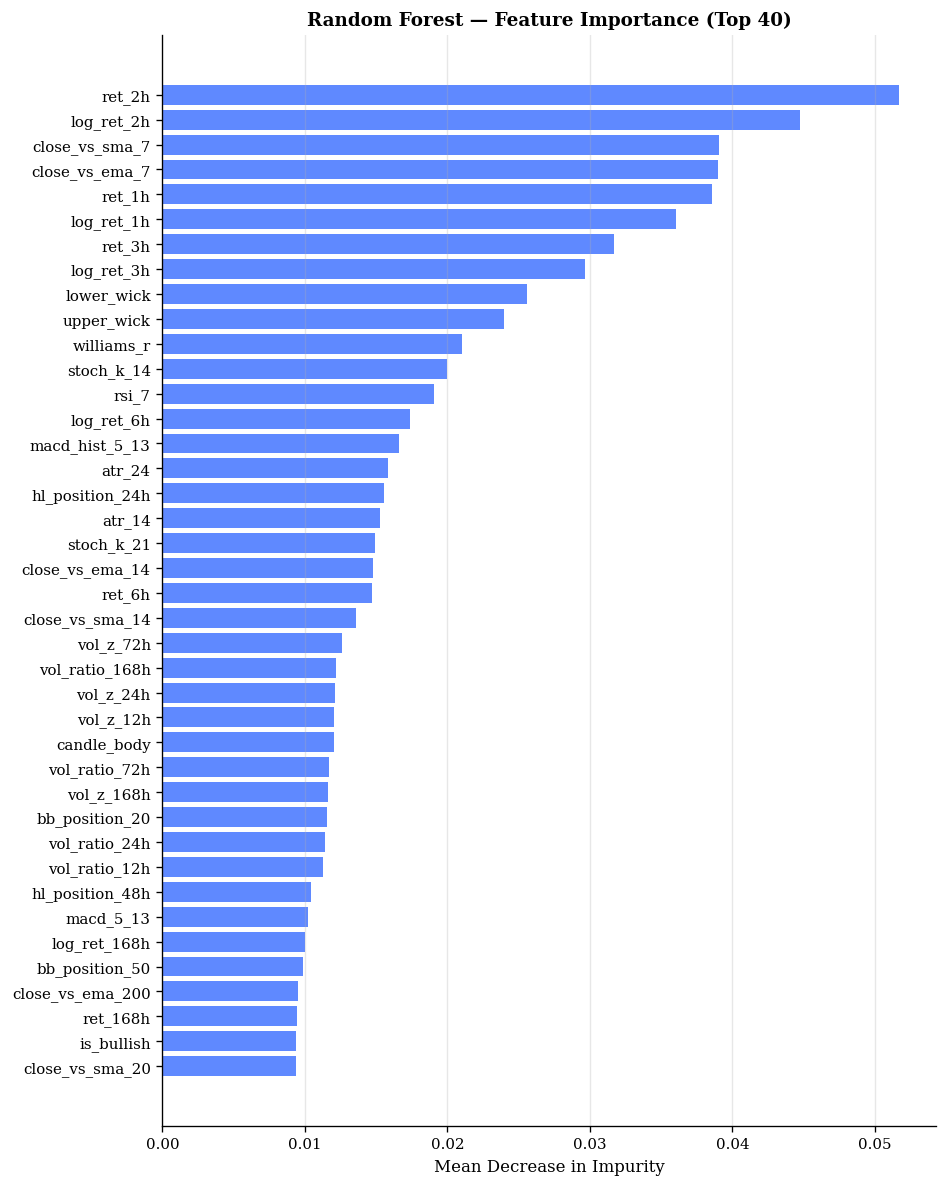

In [7]:
top40 = importance_df.head(40)
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(top40['feature'][::-1], top40['importance'][::-1], color=BLUE, alpha=0.75)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Random Forest — Feature Importance (Top 40)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_importance_rf.png')
plt.show()


## 5. Correlation filtering → top 20 features

In [8]:
corr_matrix = pd.DataFrame(X_train, columns=feature_cols).corr().abs()
ranked = importance_df['feature'].tolist()
kept, dropped_corr = [], []

for feat in ranked:
    if feat not in kept:
        too_corr = any(corr_matrix.loc[feat, k] > CORR_THRESHOLD for k in kept)
        if too_corr:
            corr_partner = next(k for k in kept if corr_matrix.loc[feat, k] > CORR_THRESHOLD)
            dropped_corr.append((feat, corr_partner, corr_matrix.loc[feat, corr_partner]))
        else:
            kept.append(feat)

selected_features = kept[:TOP_N_FEATURES]
print(f'After correlation filter: {len(kept)} features (dropped {len(dropped_corr)})')
print(f'\nSelected top {TOP_N_FEATURES}:')
for i, f in enumerate(selected_features, 1):
    imp = importance_df[importance_df['feature'] == f]['importance'].values[0]
    print(f'  {i:>2}. {f:<40} importance={imp:.4f}')


After correlation filter: 42 features (dropped 31)

Selected top 20:
   1. ret_2h                                   importance=0.0517
   2. close_vs_sma_7                           importance=0.0390
   3. ret_1h                                   importance=0.0386
   4. ret_3h                                   importance=0.0317
   5. lower_wick                               importance=0.0256
   6. upper_wick                               importance=0.0240
   7. williams_r                               importance=0.0210
   8. rsi_7                                    importance=0.0191
   9. log_ret_6h                               importance=0.0174
  10. macd_hist_5_13                           importance=0.0166
  11. atr_24                                   importance=0.0158
  12. hl_position_24h                          importance=0.0156
  13. close_vs_ema_14                          importance=0.0148
  14. vol_z_72h                                importance=0.0126
  15. vol_ratio_168h 

## 6. LightGBM — train on selected features

In [9]:
feat_idx = [feature_cols.index(f) for f in selected_features]
Xtr = X_train[:, feat_idx]
Xvl = X_val[:,   feat_idx]
Xte = X_test[:,  feat_idx]

lgb_train = lgb.Dataset(Xtr, label=y_train, feature_name=selected_features)
lgb_val   = lgb.Dataset(Xvl, label=y_val,   feature_name=selected_features, reference=lgb_train)

lgb_model = lgb.train(
    LGB_PARAMS, lgb_train,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
        lgb.log_evaluation(period=50),
    ],
)

lgb_model.save_model(str(MODELS_DIR / 'lgbm_model.txt'))
pd.Series(selected_features).to_csv(MODELS_DIR / 'lgbm_features.csv', index=False, header=False)
print(f'Best iteration: {lgb_model.best_iteration}')


[50]	train's binary_logloss: 0.680399	val's binary_logloss: 0.688614
[100]	train's binary_logloss: 0.674315	val's binary_logloss: 0.68834
Best iteration: 92


## 7. Evaluation

In [10]:
probs_val  = lgb_model.predict(Xvl)
probs_test = lgb_model.predict(Xte)

val_acc  = ((probs_val  > 0.5) == y_val).mean()
test_acc = ((probs_test > 0.5) == y_test).mean()
print(f'Val  — accuracy: {val_acc:.4f}   AUC: {roc_auc_score(y_val, probs_val):.4f}')
print(f'Test — accuracy: {test_acc:.4f}   AUC: {roc_auc_score(y_test, probs_test):.4f}')
print()
print(classification_report(y_test, (probs_test > 0.5).astype(int), target_names=['down','up']))


Val  — accuracy: 0.5376   AUC: 0.5559
Test — accuracy: 0.5298   AUC: 0.5476

              precision    recall  f1-score   support

        down       0.53      0.47      0.50      6565
          up       0.53      0.58      0.56      6683

    accuracy                           0.53     13248
   macro avg       0.53      0.53      0.53     13248
weighted avg       0.53      0.53      0.53     13248



### Confidence distribution

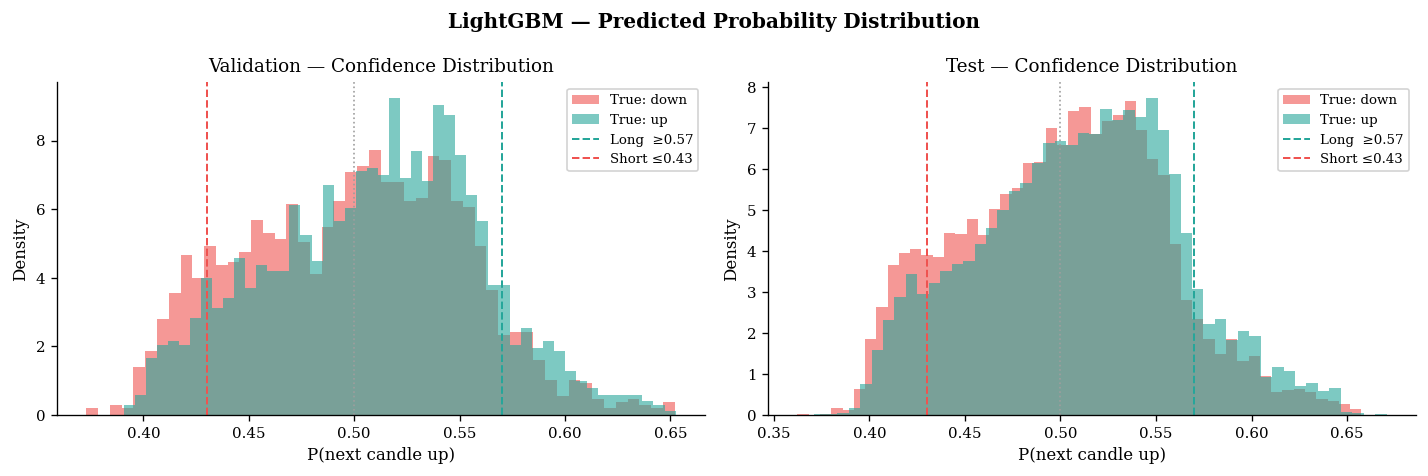

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, probs, split, y in [
    (axes[0], probs_val,  'Validation', y_val),
    (axes[1], probs_test, 'Test',       y_test),
]:
    ax.hist(probs[y==0], bins=50, alpha=0.6, color=RED,   label='True: down', density=True)
    ax.hist(probs[y==1], bins=50, alpha=0.6, color=GREEN, label='True: up',   density=True)
    ax.axvline(0.5,             color=GREY,   ls=':',  lw=1.0)
    ax.axvline(LONG_THRESHOLD,  color=GREEN,  ls='--', lw=1.2, label=f'Long  ≥{LONG_THRESHOLD}')
    ax.axvline(SHORT_THRESHOLD, color=RED,    ls='--', lw=1.2, label=f'Short ≤{SHORT_THRESHOLD}')
    ax.set_xlabel('P(next candle up)'); ax.set_ylabel('Density')
    ax.set_title(f'{split} — Confidence Distribution'); ax.legend(fontsize=8)
fig.suptitle('LightGBM — Predicted Probability Distribution', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lgbm_confidence_dist.png')
plt.show()


### Calibration curve

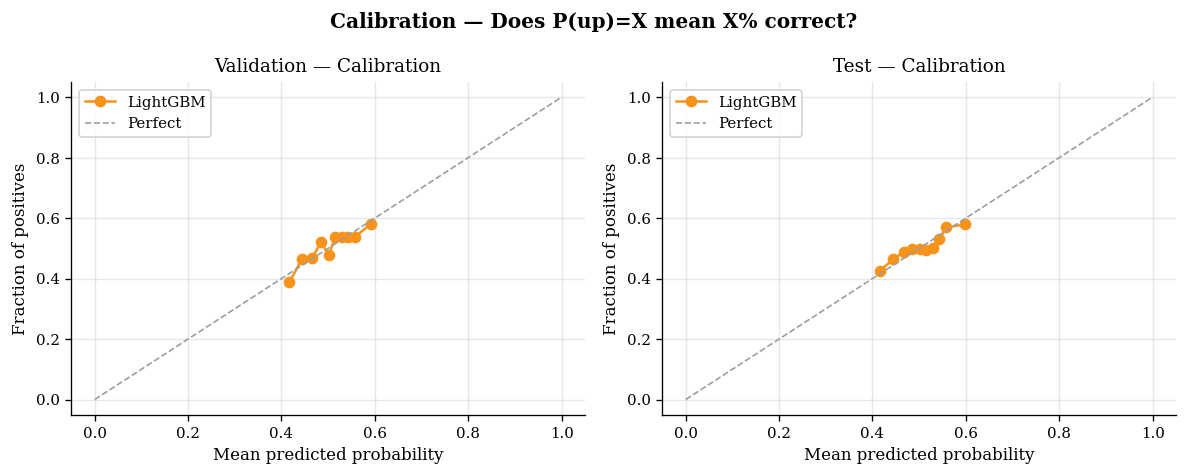

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, probs, split, y in [
    (axes[0], probs_val,  'Validation', y_val),
    (axes[1], probs_test, 'Test',       y_test),
]:
    frac_pos, mean_pred = calibration_curve(y, probs, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', color=ACCENT, lw=1.5, label='LightGBM')
    ax.plot([0,1],[0,1], ls='--', color=GREY, lw=1, label='Perfect')
    ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{split} — Calibration'); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('Calibration — Does P(up)=X mean X% correct?', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lgbm_calibration.png')
plt.show()


### Win rate by confidence bucket

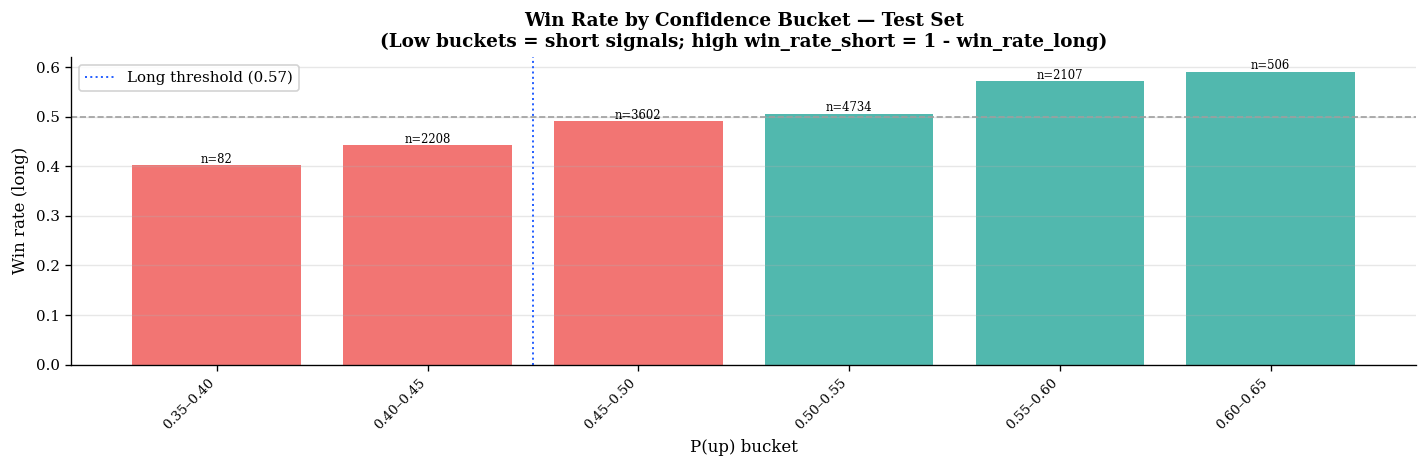

   bucket    n  win_rate_long  win_rate_short
0.35–0.40   82       0.402439        0.597561
0.40–0.45 2208       0.442935        0.557065
0.45–0.50 3602       0.490561        0.509439
0.50–0.55 4734       0.506337        0.493663
0.55–0.60 2107       0.571903        0.428097
0.60–0.65  506       0.590909        0.409091


In [13]:
rows = []
for lo in np.arange(0.5, 1.0, 0.05):
    hi   = lo + 0.05
    mask = (probs_test >= lo) & (probs_test < hi)
    n    = mask.sum()
    if n < 10: continue
    rows.append({'bucket': f'{lo:.2f}–{hi:.2f}', 'n': n,
                 'win_rate_long': (y_test[mask] == 1).mean()})

# Short side: low probability = confident down
for lo in np.arange(0.0, 0.5, 0.05):
    hi   = lo + 0.05
    mask = (probs_test >= lo) & (probs_test < hi)
    n    = mask.sum()
    if n < 10: continue
    rows.append({'bucket': f'{lo:.2f}–{hi:.2f}', 'n': n,
                 'win_rate_long': (y_test[mask] == 1).mean()})

bucket_df = pd.DataFrame(rows).sort_values('bucket')
bucket_df['win_rate_short'] = 1 - bucket_df['win_rate_long']

fig, ax = plt.subplots(figsize=(12, 4))
colors = [GREEN if r > 0.5 else RED for r in bucket_df['win_rate_long']]
ax.bar(range(len(bucket_df)), bucket_df['win_rate_long'], color=colors, alpha=0.8)
ax.axhline(0.5, color=GREY, ls='--', lw=1)
ax.axvline(bucket_df[bucket_df['bucket'] >= f'{LONG_THRESHOLD:.2f}'].index[0] - 0.5
           if not bucket_df[bucket_df['bucket'] >= f'{LONG_THRESHOLD:.2f}'].empty else len(bucket_df),
           color=BLUE, ls=':', lw=1.2, label=f'Long threshold ({LONG_THRESHOLD})')
ax.set_xticks(range(len(bucket_df)))
ax.set_xticklabels(bucket_df['bucket'], rotation=45, ha='right', fontsize=8)
for i, row in bucket_df.reset_index(drop=True).iterrows():
    ax.text(i, row['win_rate_long'] + 0.005, f"n={row['n']}", ha='center', fontsize=7)
ax.set_xlabel('P(up) bucket'); ax.set_ylabel('Win rate (long)')
ax.set_title('Win Rate by Confidence Bucket — Test Set\n'
             '(Low buckets = short signals; high win_rate_short = 1 - win_rate_long)',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lgbm_win_rate_by_confidence.png')
plt.show()
print(bucket_df[['bucket','n','win_rate_long','win_rate_short']].to_string(index=False))


## 8. Backtest — Long & Short

**Long entry:** `P(up) ≥ LONG_THRESHOLD` (0.57) and flat and not in cooldown.

**Short entry:** `P(up) ≤ SHORT_THRESHOLD` (0.43) and flat and not in cooldown.

**SL:** `max(ATR_MULTIPLIER × ATR(14), MIN_SL)` — computed at entry time.

**Exit priority:** SL → TP → max hold (48h) → confidence exit after min hold (6h).

> **Threshold rationale:** The model's predicted probabilities are well-calibrated but compressed
> into ~0.35–0.65. Win-rate-by-bucket analysis shows genuine edge from P(up) ≥ 0.57 (long)
> and P(up) ≤ 0.43 (short), matching observed bucket win rates of 57–59% and 56–60% respectively.

In [14]:
close_arr  = test_df['close'].values
atr_arr    = test_df['atr_14_pct'].values
sma200_arr = test_df['sma_200'].values
sig_index  = test_df.index

cash = 1.0; units = 0.0
in_pos = False; direction = None
entry_px = 0.0; entry_ts = None
entry_cash = 0.0           # cash at the time of short entry (notional)
dynamic_sl = 0.0
hold_count = 0; cooldown = 0

equity_curve = [1.0]
trade_log    = []

for i, (ts, px, conf, atr_pct, sma200) in enumerate(
    zip(sig_index, close_arr, probs_test, atr_arr, sma200_arr)
):
    if cooldown > 0:
        cooldown -= 1

    if in_pos:
        hold_count += 1

        pnl   = (px - entry_px) / entry_px if direction == 'long' \
               else (entry_px - px) / entry_px
        reason = None

        if pnl <= -dynamic_sl:                                               reason = 'sl'
        elif pnl >= TAKE_PROFIT:                                             reason = 'tp'
        elif hold_count >= MAX_HOLD_CANDLES:                                 reason = 'max_hold'
        elif hold_count >= MIN_HOLD_CANDLES:
            if direction == 'long'  and conf < EXIT_THRESHOLD_LONG:          reason = 'conf'
            elif direction == 'short' and conf > EXIT_THRESHOLD_SHORT:       reason = 'conf'

        if reason:
            if direction == 'long':
                cash = units * px
            else:
                # short PnL: notional × pnl (positive = price dropped)
                cash = entry_cash * (1 + pnl)
            units = 0.0
            trade_log.append({
                'entry_time': entry_ts, 'exit_time': ts,
                'direction':  direction, 'entry_px': entry_px, 'exit_px': px,
                'pnl_pct':    pnl,       'reason':   reason,   'hold_h': hold_count,
                'dynamic_sl': dynamic_sl,
            })
            in_pos     = False; direction = None
            hold_count = 0;     cooldown  = COOLDOWN_CANDLES

    if not in_pos and cooldown == 0:
        sl = max(ATR_MULTIPLIER * atr_pct, MIN_SL)
        if conf >= LONG_THRESHOLD:
            units      = cash / px
            cash       = 0.0; in_pos = True; direction = 'long'
            entry_px   = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl
        elif conf <= SHORT_THRESHOLD:
            entry_cash = cash          # snapshot notional for PnL
            units      = cash / px     # notional units shorted
            in_pos     = True; direction = 'short'
            entry_px   = px; entry_ts = ts; hold_count = 0; dynamic_sl = sl

    # Mark-to-market equity
    if in_pos and direction == 'long':
        equity_curve.append(units * px)
    elif in_pos and direction == 'short':
        unreal_pnl = (entry_px - px) / entry_px
        equity_curve.append(entry_cash * (1 + unreal_pnl))
    else:
        equity_curve.append(cash)

# Force close
if in_pos:
    px  = close_arr[-1]
    pnl = (px - entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px
    final_cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
    trade_log.append({'entry_time': entry_ts, 'exit_time': sig_index[-1],
                      'direction': direction, 'entry_px': entry_px, 'exit_px': px,
                      'pnl_pct': pnl, 'reason': 'eod', 'hold_h': hold_count,
                      'dynamic_sl': dynamic_sl})
    equity_curve[-1] = final_cash

equity_arr = np.array(equity_curve[1:])
trades_df  = pd.DataFrame(trade_log)

print(f'Total trades: {len(trades_df)}')
if not trades_df.empty:
    print(trades_df.groupby(['direction','reason']).size().to_string())
    print(f'\nAvg SL used:         {trades_df["dynamic_sl"].mean()*100:.2f}%')
    print(f'Avg hold:            {trades_df["hold_h"].mean():.1f}h')
    print(f'Median hold:         {trades_df["hold_h"].median():.1f}h')

Total trades: 833
direction  reason
long       conf      323
           sl         78
           tp         14
short      conf      346
           sl         66
           tp          6

Avg SL used:         1.69%
Avg hold:            8.0h
Median hold:         7.0h


## 9. Buy-and-hold benchmark

In [15]:
bh_units  = 1.0 / close_arr[0]
bh_equity = bh_units * close_arr
bh_final  = bh_equity[-1]

## 10. Metrics

In [16]:
def sharpe(eq, ann=24*365):
    r = np.log(eq[1:] / (eq[:-1] + 1e-12))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(ann)) if len(r) > 1 else 0.0

def max_dd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

long_trades  = trades_df[trades_df['direction']=='long']  if not trades_df.empty else pd.DataFrame()
short_trades = trades_df[trades_df['direction']=='short'] if not trades_df.empty else pd.DataFrame()

metrics = pd.DataFrame([
    {'Strategy':      'LightGBM L+S',
     'Total Return':  f'{(equity_arr[-1]-1)*100:.2f}%',
     'Sharpe (ann.)': f'{sharpe(equity_arr):.3f}',
     'Max Drawdown':  f'{max_dd(equity_arr)*100:.2f}%',
     'Trades (L/S)':  f'{len(long_trades)}/{len(short_trades)}',
     'Win Rate':      f'{(trades_df["pnl_pct"]>0).mean()*100:.1f}%' if not trades_df.empty else 'N/A',
     'Avg Hold (h)':  f'{trades_df["hold_h"].mean():.1f}' if not trades_df.empty else 'N/A',
     'Avg SL':        f'{trades_df["dynamic_sl"].mean()*100:.2f}%' if not trades_df.empty else 'N/A',
    },
    {'Strategy':      'Buy & Hold',
     'Total Return':  f'{(bh_final-1)*100:.2f}%',
     'Sharpe (ann.)': f'{sharpe(bh_equity):.3f}',
     'Max Drawdown':  f'{max_dd(bh_equity)*100:.2f}%',
     'Trades (L/S)':  '1/0', 'Win Rate': 'N/A',
     'Avg Hold (h)':  'N/A', 'Avg SL': 'N/A',
    },
]).set_index('Strategy')
print(metrics.to_string())


             Total Return Sharpe (ann.) Max Drawdown Trades (L/S) Win Rate Avg Hold (h) Avg SL
Strategy                                                                                      
LightGBM L+S       51.81%         0.881      -31.02%      415/418    59.5%          8.0  1.69%
Buy & Hold          3.14%         0.044      -50.08%          1/0      N/A          N/A    N/A


## 11. Results plot

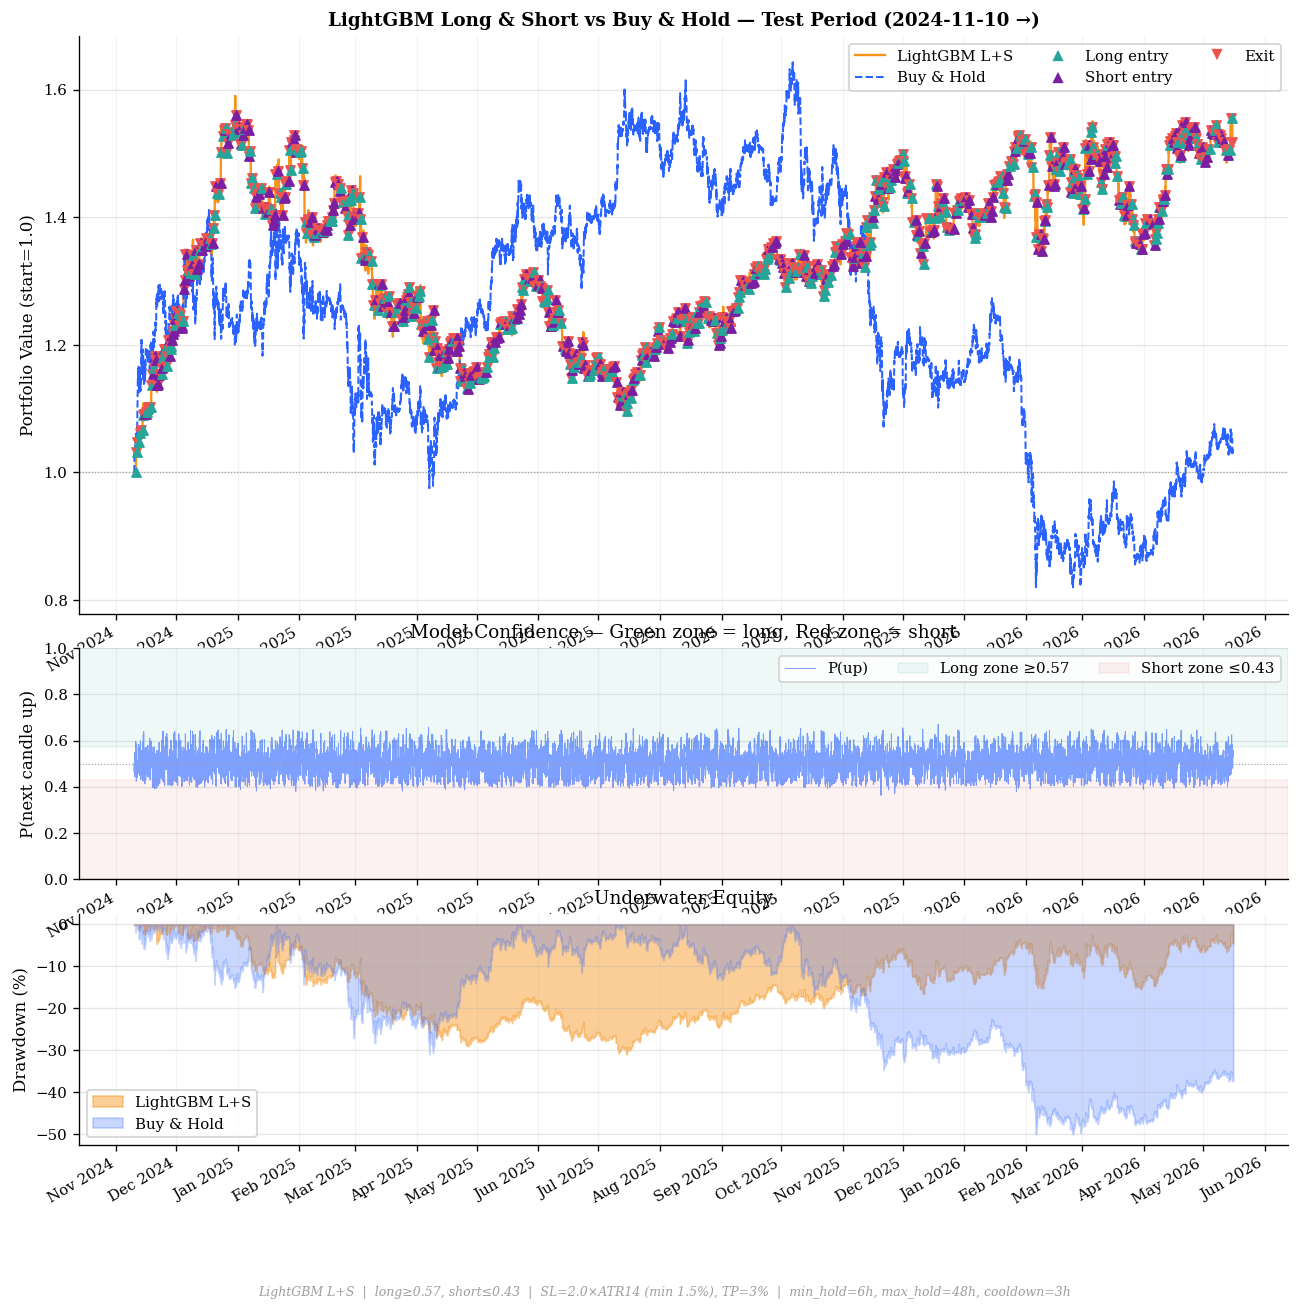

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12),
                         gridspec_kw={'height_ratios':[3,1.2,1.2], 'hspace':0.10})

# Equity
ax = axes[0]
ax.plot(sig_index, equity_arr, color=ACCENT, lw=1.4, label='LightGBM L+S')
ax.plot(sig_index, bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
if not trades_df.empty:
    eq_s = pd.Series(equity_arr, index=sig_index)
    for _, row in trades_df.iterrows():
        ei  = eq_s.index.get_indexer([row['entry_time']], method='nearest')[0]
        xi  = eq_s.index.get_indexer([row['exit_time']],  method='nearest')[0]
        col = GREEN if row['direction'] == 'long' else PURPLE
        ax.scatter(eq_s.index[ei], equity_arr[ei], marker='^', color=col,  s=30, zorder=5)
        ax.scatter(eq_s.index[xi], equity_arr[xi], marker='v', color=RED,  s=30, zorder=5)
    from matplotlib.lines import Line2D
    handles = list(ax.get_legend_handles_labels()[0]) + [
        Line2D([0],[0],marker='^',color='w',markerfacecolor=GREEN, markersize=8,label='Long entry'),
        Line2D([0],[0],marker='^',color='w',markerfacecolor=PURPLE,markersize=8,label='Short entry'),
        Line2D([0],[0],marker='v',color='w',markerfacecolor=RED,   markersize=8,label='Exit'),
    ]
    ax.legend(handles=handles, ncol=3)
ax.set_ylabel('Portfolio Value (start=1.0)')
ax.set_title('LightGBM Long & Short vs Buy & Hold — Test Period (2024-11-10 →)',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# Confidence with long/short zones
ax = axes[1]
ax.plot(sig_index, probs_test, color=BLUE, lw=0.6, alpha=0.6, label='P(up)')
ax.axhspan(LONG_THRESHOLD,  1.0, alpha=0.08, color=GREEN, label=f'Long zone ≥{LONG_THRESHOLD}')
ax.axhspan(0.0, SHORT_THRESHOLD, alpha=0.08, color=RED,   label=f'Short zone ≤{SHORT_THRESHOLD}')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0, 1); ax.set_ylabel('P(next candle up)')
ax.set_title('Model Confidence — Green zone = long, Red zone = short')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# Drawdown
ax = axes[2]
pk_l = np.maximum.accumulate(equity_arr)
pk_b = np.maximum.accumulate(bh_equity)
ax.fill_between(sig_index, (equity_arr-pk_l)/(pk_l+1e-12)*100, 0,
                color=ACCENT, alpha=0.45, label='LightGBM L+S')
ax.fill_between(sig_index, (bh_equity-pk_b)/(pk_b+1e-12)*100,  0,
                color=BLUE,   alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.set_title('Underwater Equity')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'LightGBM L+S  |  long≥{LONG_THRESHOLD}, short≤{SHORT_THRESHOLD}  |  '
    f'SL={ATR_MULTIPLIER}×ATR14 (min {MIN_SL*100:.1f}%), TP={TAKE_PROFIT*100:.0f}%  |  '
    f'min_hold={MIN_HOLD_CANDLES}h, max_hold={MAX_HOLD_CANDLES}h, cooldown={COOLDOWN_CANDLES}h',
    ha='center', fontsize=7.5, color=GREY, style='italic')

fig.savefig(FIGURES_DIR / 'lgbm_backtest_results.png')
plt.show()

## 12. Trade log

In [18]:
if not trades_df.empty:
    trades_df['pnl_fmt'] = trades_df['pnl_pct'].apply(lambda x: f'{x*100:+.2f}%')
    trades_df['sl_fmt']  = trades_df['dynamic_sl'].apply(lambda x: f'{x*100:.2f}%')
    display(trades_df[['entry_time','exit_time','direction','hold_h',
                        'entry_px','exit_px','pnl_fmt','sl_fmt','reason']])


,entry_time,exit_time,direction,hold_h,entry_px,exit_px,pnl_fmt,sl_fmt,reason
0,2024-11-10 20:00:00,2024-11-11 02:00:00,long,6,78950.01,81431.17,+3.14%,1.62%,tp
1,2024-11-11 06:00:00,2024-11-11 12:00:00,long,6,80900.68,82168.91,+1.57%,2.48%,conf
2,2024-11-12 09:00:00,2024-11-12 18:00:00,long,9,87630.89,88796.41,+1.33%,3.16%,conf
3,2024-11-13 03:00:00,2024-11-13 10:00:00,long,7,87136.00,87535.55,+0.46%,3.00%,conf
4,2024-11-14 06:00:00,2024-11-14 12:00:00,long,6,89300.69,91243.17,+2.18%,2.77%,conf
...,...,...,...,...,...,...,...,...,...
828,2026-05-12 03:00:00,2026-05-12 18:00:00,long,15,81058.80,80679.12,-0.47%,1.50%,conf
829,2026-05-13 03:00:00,2026-05-13 10:00:00,short,7,81249.99,80809.01,+0.54%,1.50%,conf
830,2026-05-13 13:00:00,2026-05-13 19:00:00,long,6,79656.01,79642.41,-0.02%,1.50%,conf
831,2026-05-14 11:00:00,2026-05-14 16:00:00,long,5,79258.27,81888.40,+3.32%,1.50%,tp


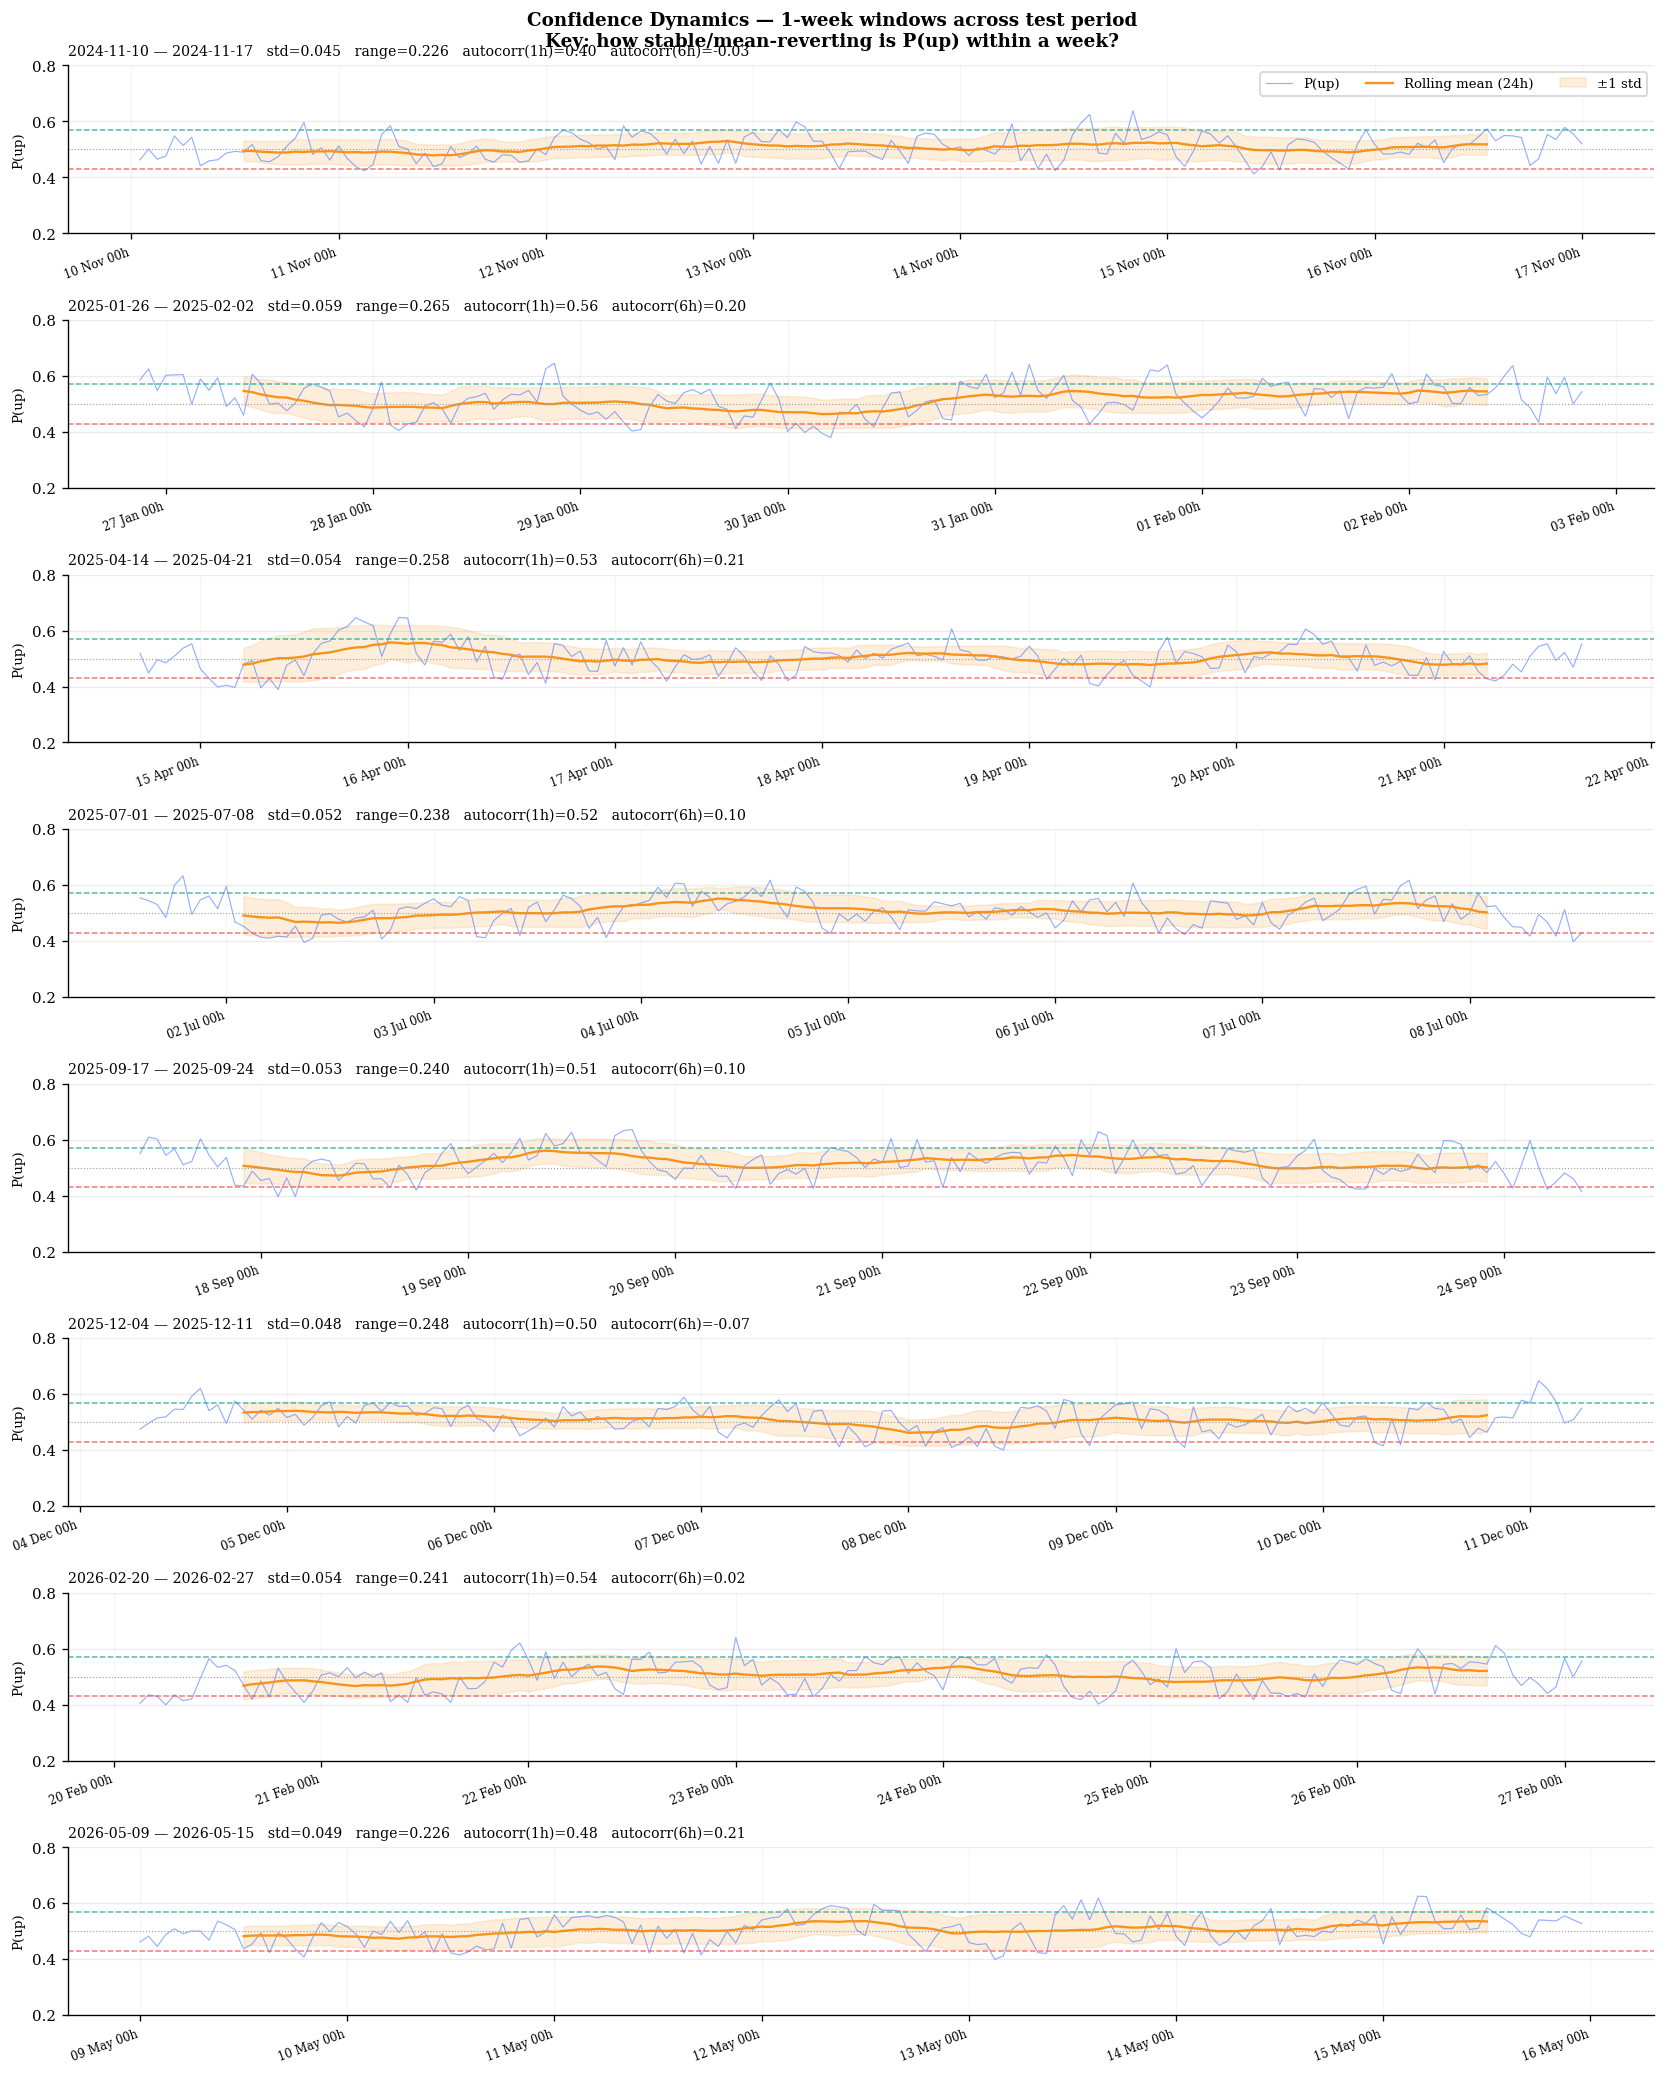

week_start  mean   std  range  time_above_long  time_below_short  autocorr_1h  autocorr_6h
2024-11-10 0.507 0.045  0.226            0.071             0.030        0.403       -0.027
2025-01-26 0.517 0.059  0.265            0.185             0.083        0.556        0.199
2025-04-14 0.501 0.054  0.258            0.083             0.119        0.528        0.210
2025-07-01 0.507 0.052  0.238            0.101             0.113        0.520        0.096
2025-09-17 0.516 0.053  0.240            0.155             0.065        0.509        0.102
2025-12-04 0.513 0.048  0.248            0.089             0.083        0.503       -0.067
2026-02-20 0.502 0.054  0.241            0.071             0.119        0.540        0.023
2026-05-09 0.506 0.049  0.226            0.095             0.083        0.482        0.212


In [19]:
# ── Confidence dynamics over a rolling 1-week window ─────────────────────────
EXPLORE_WEEKS    = 8          # how many weeks to sample
WINDOW_H         = 168        # 1 week in hours
ROLLING_STD_H    = 24         # rolling std window (hours) — smoothing
CONF_BAND_ALPHA  = 0.15       # shading transparency

# Pick evenly-spaced week windows from test set
n_test    = len(probs_test)
starts    = np.linspace(0, n_test - WINDOW_H - 1, EXPLORE_WEEKS, dtype=int)

fig, axes = plt.subplots(EXPLORE_WEEKS, 1, figsize=(14, EXPLORE_WEEKS * 2.2),
                          sharex=False, sharey=True)

for ax, start in zip(axes, starts):
    end   = start + WINDOW_H
    confs = probs_test[start:end]
    times = sig_index[start:end]

    # rolling std of confidence (how much it jumps around)
    conf_s   = pd.Series(confs, index=times)
    roll_std = conf_s.rolling(ROLLING_STD_H, center=True).std()
    roll_mu  = conf_s.rolling(ROLLING_STD_H, center=True).mean()

    # ── raw confidence
    ax.plot(times, confs, color=BLUE, lw=0.7, alpha=0.5, label='P(up)')

    # ── rolling mean ± 1 std band
    ax.plot(times, roll_mu, color=ACCENT, lw=1.4, label=f'Rolling mean ({ROLLING_STD_H}h)')
    ax.fill_between(times,
                    roll_mu - roll_std,
                    roll_mu + roll_std,
                    color=ACCENT, alpha=CONF_BAND_ALPHA, label='±1 std')

    # ── threshold lines
    ax.axhline(LONG_THRESHOLD,  color=GREEN, ls='--', lw=0.9, alpha=0.8)
    ax.axhline(SHORT_THRESHOLD, color=RED,   ls='--', lw=0.9, alpha=0.8)
    ax.axhline(0.5,             color=GREY,  ls=':',  lw=0.7)

    # ── annotate variance stats
    weekly_std  = confs.std()
    weekly_range = confs.max() - confs.min()
    autocorr_1h = pd.Series(confs).autocorr(lag=1)
    autocorr_6h = pd.Series(confs).autocorr(lag=6)

    ax.set_title(
        f'{times[0].date()} — {times[-1].date()}   '
        f'std={weekly_std:.3f}   range={weekly_range:.3f}   '
        f'autocorr(1h)={autocorr_1h:.2f}   autocorr(6h)={autocorr_6h:.2f}',
        fontsize=8.5, loc='left'
    )
    ax.set_ylim(0.2, 0.8)
    ax.set_ylabel('P(up)', fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    ax.grid(axis='x', alpha=0.1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Hh'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=7)

axes[0].legend(ncol=3, fontsize=8, loc='upper right')

fig.suptitle(
    'Confidence Dynamics — 1-week windows across test period\n'
    'Key: how stable/mean-reverting is P(up) within a week?',
    fontweight='bold', fontsize=11
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'confidence_weekly_dynamics.png')
plt.show()

# ── summary table across all weeks ───────────────────────────────────────────
rows = []
for start in starts:
    end   = start + WINDOW_H
    confs = probs_test[start:end]
    rows.append({
        'week_start':    sig_index[start].date(),
        'mean':          confs.mean(),
        'std':           confs.std(),
        'range':         confs.max() - confs.min(),
        'time_above_long':  (confs >= LONG_THRESHOLD).mean(),
        'time_below_short': (confs <= SHORT_THRESHOLD).mean(),
        'autocorr_1h':   pd.Series(confs).autocorr(lag=1),
        'autocorr_6h':   pd.Series(confs).autocorr(lag=6),
    })

dynamics_df = pd.DataFrame(rows)
print(dynamics_df.to_string(index=False, float_format='{:.3f}'.format))

In [20]:
if trades_df.empty:
    print('No trades — cannot produce summary.')
else:
    pnl = trades_df['pnl_pct']
    long_t  = trades_df[trades_df['direction'] == 'long']
    short_t = trades_df[trades_df['direction'] == 'short']
    winning = trades_df[pnl > 0]
    losing  = trades_df[pnl <= 0]

    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    pnl_pct_series = pnl * 100

    print('=' * 58)
    print('  STRATEGY SUMMARY — LightGBM Long & Short')
    print('=' * 58)

    print('\n── Trade counts ─────────────────────────────────────────')
    print(f'  Total trades        : {len(trades_df)}')
    print(f'    Long              : {len(long_t)}')
    print(f'    Short             : {len(short_t)}')
    print(f'  Winning trades      : {len(winning)}  ({len(winning)/len(trades_df)*100:.1f}%)')
    print(f'  Losing trades       : {len(losing)}  ({len(losing)/len(trades_df)*100:.1f}%)')

    print('\n── Exit reasons ─────────────────────────────────────────')
    for reason, grp in trades_df.groupby('reason'):
        wr = (grp['pnl_pct'] > 0).mean() * 100
        print(f'  {reason:<12}  n={len(grp):>3}   win_rate={wr:.1f}%   '
              f'avg_pnl={grp["pnl_pct"].mean()*100:+.2f}%')

    print('\n── Return percentiles (% per trade) ─────────────────────')
    print(f'  {"Percentile":<12}  {"Return":>8}')
    print(f'  {"-"*22}')
    for p in percentiles:
        val = float(pnl_pct_series.quantile(p / 100))
        print(f'  p{p:<11}  {val:>+7.2f}%')
    print(f'  {"mean":<12}  {pnl_pct_series.mean():>+7.2f}%')
    print(f'  {"std":<12}  {pnl_pct_series.std():>7.2f}%')
    print(f'  {"best":<12}  {pnl_pct_series.max():>+7.2f}%')
    print(f'  {"worst":<12}  {pnl_pct_series.min():>+7.2f}%')

    print('\n── Hold duration (hours) ────────────────────────────────')
    print(f'  Mean                : {trades_df["hold_h"].mean():.1f}h')
    print(f'  Median              : {trades_df["hold_h"].median():.1f}h')
    print(f'  Min / Max           : {trades_df["hold_h"].min()}h / {trades_df["hold_h"].max()}h')

    print('\n── Portfolio result ─────────────────────────────────────')
    print(f'  Final equity        : {equity_arr[-1]:.4f}  (started at 1.0000)')
    print(f'  Total return        : {(equity_arr[-1] - 1) * 100:+.2f}%')
    print(f'  Buy-and-hold return : {(bh_final - 1) * 100:+.2f}%')
    print(f'  Alpha               : {(equity_arr[-1] - bh_final) * 100:+.2f}pp')
    print(f'  Sharpe (ann.)       : {sharpe(equity_arr):.3f}')
    print(f'  Max drawdown        : {max_dd(equity_arr) * 100:.2f}%')
    print('=' * 58)


  STRATEGY SUMMARY — LightGBM Long & Short

── Trade counts ─────────────────────────────────────────
  Total trades        : 833
    Long              : 415
    Short             : 418
  Winning trades      : 496  (59.5%)
  Losing trades       : 337  (40.5%)

── Exit reasons ─────────────────────────────────────────
  conf          n=669   win_rate=71.2%   avg_pnl=+0.43%
  sl            n=144   win_rate=0.0%   avg_pnl=-2.13%
  tp            n= 20   win_rate=100.0%   avg_pnl=+3.59%

── Return percentiles (% per trade) ─────────────────────
  Percentile      Return
  ----------------------
  p1              -3.40%
  p5              -2.24%
  p10             -1.81%
  p25             -0.49%
  p50             +0.20%
  p75             +0.77%
  p90             +1.51%
  p95             +2.16%
  p99             +3.31%
  mean            +0.06%
  std              1.34%
  best            +5.64%
  worst           -5.11%

── Hold duration (hours) ────────────────────────────────
  Mean              